In [8]:
%matplotlib inline

import numpy as np
from roboticstoolbox.robot.ERobot import ERobot
from matplotlib import pyplot
from roboticstoolbox import DHRobot, RevoluteDH, RevoluteMDH
from spatialmath import SE3
import os

<p align="center">
    <img src="./src/robot_description/image.png" alt="robot">
</p>

ERobot: ROBOT, 3 joints (RRR), geometry
┌──────┬───────────────┬───────┬────────┬───────────────────────────────────────────┐
│ link │     link      │ joint │ parent │            ETS: parent to link            │
├──────┼───────────────┼───────┼────────┼───────────────────────────────────────────┤
│    0 │ link_0        │       │ BASE   │ SE3()                                     │
│    1 │ link_1        │     0 │ link_0 │ SE3(0, 0, 0.2) ⊕ Rz(q0)                   │
│    2 │ link_2        │     1 │ link_1 │ SE3(0, -0.12, 0; 0°, -90°, -90°) ⊕ Rz(q1) │
│    3 │ link_3        │     2 │ link_2 │ SE3(0.25, 0, 0.1) ⊕ Rz(q2)                │
│    4 │ @end_effector │       │ link_3 │ SE3(0.28, 0, 0; 90°, -0°, 90°)            │
└──────┴───────────────┴───────┴────────┴───────────────────────────────────────────┘

┌──────┬─────┬─────┬─────┐
│ name │ q0  │ q1  │ q2  │
├──────┼─────┼─────┼─────┤
│   qz │  0° │  0° │  0° │
└──────┴─────┴─────┴─────┘


Forward kinematics at zero configuration:
   1  

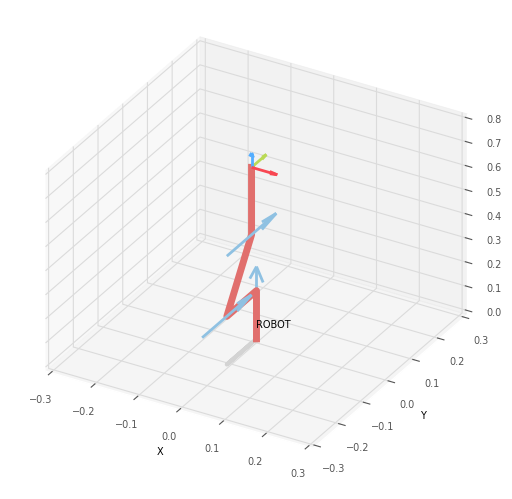

PyPlot3D backend, t = 0.05, scene:
  robot: Text(0.0, 0.0, 'ROBOT')

<Figure size 640x480 with 0 Axes>

In [9]:
class MyRobot(ERobot):
    def __init__(self):
        # Get the current working directory and construct the path to the URDF file
        current_dir = os.getcwd()
        urdf_path = os.path.join(current_dir, "src/robot_description/urdf/my-robot.xacro")
        
        links, name, urdf_string, urdf_filepath = ERobot.URDF_read(urdf_path)
        super().__init__(
            links,
            name=name.upper(),
            manufacturer="",
            urdf_string=urdf_string,
            urdf_filepath=urdf_filepath,
        )

        self.qz = np.zeros(self.n)
        self.addconfiguration("qz", self.qz)

robot = MyRobot()
print(robot)
print("\nForward kinematics at zero configuration:")
print(robot.fkine(robot.qz))

robot.plot([0,0,0], backend='pyplot', block=False, limits=[-0.3, 0.3, -0.3, 0.3, 0, 0.8])


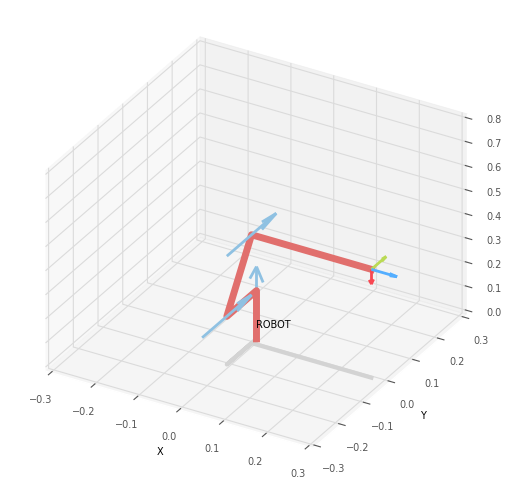

PyPlot3D backend, t = 0.05, scene:
  robot: Text(0.0, 0.0, 'ROBOT')

<Figure size 640x480 with 0 Axes>

In [10]:
# tesing move joints at joint 3 at -90 degree
robot.qz = [0, 0, np.pi/2]
robot.plot(robot.qz, backend='pyplot', block=False, limits=[-0.3, 0.3, -0.3, 0.3, 0, 0.8])

In [11]:
T = robot.fkine(robot.qz)
current_pos = T.t
target_pos = np.array([0.2, 0.3, 0.5])
# Compute position error
error = target_pos - current_pos
error_norm = np.linalg.norm(error)
print("Current Position:", current_pos)
print("Target Position:", target_pos)
print("Position Error:", error)
print("Error Norm:", error_norm)


Current Position: [ 0.27999987 -0.01999996  0.45000013]
Target Position: [0.2 0.3 0.5]
Position Error: [-0.07999987  0.31999996  0.04999987]
Error Norm: 0.3336164564722086



Arrived at the target position at iteration 1453!


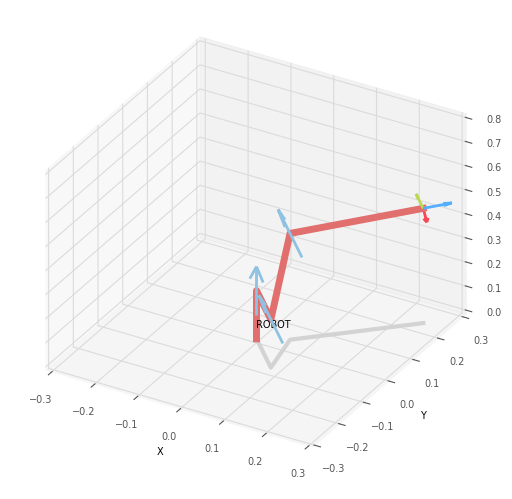


Total simulation time: 14.530s
Total iterations: 1453
Final position: [0.26036972 0.22383411 0.47654824]
Target position: [0.2 0.3 0.5]
Final error: 0.099979


<Figure size 640x480 with 0 Axes>

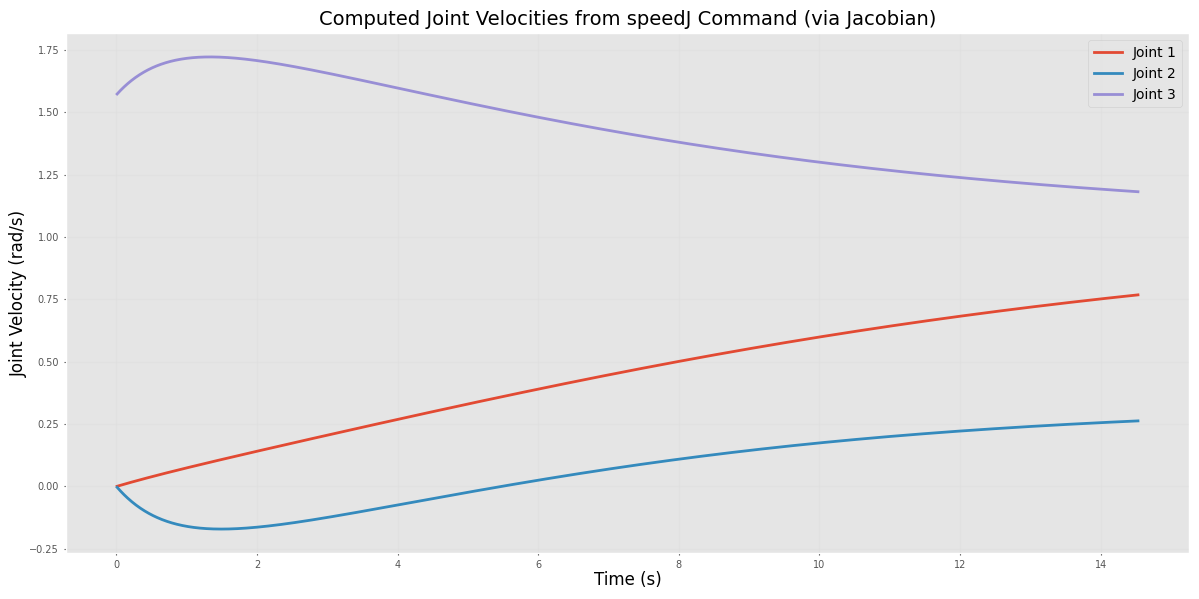

In [12]:
import matplotlib.pyplot as plt

arrived = False
dt = 0.01  # Fixed time step (simulation time, not real time)
computed_joint_velocities = []
time_stamps = []                 # Record the cumulative simulation time for each iteration
cumulative_time = 0.0            # Track total elapsed time
max_iterations = 10000           # Safety limit to prevent infinite loop
threshold = 0.1                  # Position error threshold for arrival
iteration = 0
while not arrived:
    T = robot.fkine(robot.qz)
    current_pos = T.t
    
    # Compute position error
    error = target_pos - current_pos
    error_norm = np.linalg.norm(error)
    
    if error_norm < threshold:
        arrived = True
        print(f"\nArrived at the target position at iteration {iteration}!")
        break
    
    # Simple proportional controller for velocity
    Kp = 1.0
    v = Kp * error
    
    # Compute Jacobian at current configuration
    J = robot.jacob0(robot.qz)
    J_pos = J[:3, :]  # Position part only

    condJ = np.linalg.cond(J_pos)
    if condJ > 1e12:
        print(f"Warning: Jacobian is ill-conditioned (cond={condJ:.2e}) at iteration {iteration}.")
        break

    # Create a 6D velocity vector (3 for position, 3 for orientation)
    v_6d = np.concatenate([v, np.zeros(3)])
    # Compute joint velocities using the pseudoinverse of the Jacobian
    qd = np.linalg.pinv(J) @ v_6d
    
    # Update joint angles
    robot.qz = robot.qz + qd * dt
    # Store data for plotting
    computed_joint_velocities.append(robot.qz)
    cumulative_time += dt
    time_stamps.append(cumulative_time)
    
    iteration += 1

    
# Convert the list of computed joint velocities to a numpy array.
computed_joint_velocities = np.array(computed_joint_velocities)  # Shape: (num_steps, num_joints)
robot.plot(robot.qz, backend='pyplot', block=False, limits=[-0.3, 0.3, -0.3, 0.3, 0, 0.8])
print(f"\nTotal simulation time: {cumulative_time:.3f}s")
print(f"Total iterations: {len(time_stamps)}")
print(f"Final position: {robot.fkine(robot.qz).t}")
print(f"Target position: {target_pos}")
print(f"Final error: {np.linalg.norm(target_pos - robot.fkine(robot.qz).t):.6f}")

# --- Plotting the Computed Joint Velocities ---
plt.figure(figsize=(12, 6))
num_joints = computed_joint_velocities.shape[1]
for j in range(num_joints):
    plt.plot(time_stamps, computed_joint_velocities[:, j], label=f'Joint {j+1}', linewidth=2)
plt.xlabel("Time (s)", fontsize=12)
plt.ylabel("Joint Velocity (rad/s)", fontsize=12)
plt.title("Computed Joint Velocities from speedJ Command (via Jacobian)", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
